In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/diamonds.csv')


In [ ]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [ ]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
print("Shape:", df.shape)


Shape: (53940, 11)


In [ ]:
print(df.isnull().sum())


Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64


In [ ]:
print("\nDuplicates Before:", df.duplicated().sum())



Duplicates Before: 0


In [ ]:
df.drop_duplicates(inplace=True)
print("Duplicates After:", df.duplicated().sum())


Duplicates After: 0


In [ ]:
numeric = df.select_dtypes(include=np.number)
for col in numeric.columns:
    df[col].fillna(df[col].median())


In [ ]:
categorical = df.select_dtypes(include='object')
for col in categorical.columns:
    df[col].fillna(df[col].mode()[0])


In [ ]:
numeric = df.select_dtypes(include=np.number)

for col in numeric.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("Outliers treated successfully.")

Outliers treated successfully.


In [ ]:
df.select_dtypes(include='object').describe()

,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


In [ ]:
numeric = df.select_dtypes(include=np.number)


In [ ]:
print("Mean")
print(numeric.mean())

Mean
Unnamed: 0    26970.500000
carat             0.792558
depth            61.749156
table            57.438561
price          3732.145690
x                 5.731285
y                 5.733311
z                 3.538500
dtype: float64


In [ ]:
print("\nMedian")
print(numeric.median())


Median
Unnamed: 0    26970.50
carat             0.70
depth            61.80
table            57.00
price          2401.00
x                 5.70
y                 5.71
z                 3.53
dtype: float64


In [ ]:
print("\nMode")
print(numeric.mode().iloc[0])


Mode
Unnamed: 0        1.000
carat             0.300
depth            62.000
table            56.000
price         11885.625
x                 4.370
y                 4.340
z                 2.700
Name: 0, dtype: float64


In [ ]:
print("\nVariance")
print(numeric.var())


Variance
Unnamed: 0    2.424648e+08
carat         2.089299e-01
depth         1.613546e+00
table         4.670523e+00
price         1.181138e+07
x             1.254301e+00
y             1.236433e+00
z             4.795481e-01
dtype: float64


In [ ]:
print("\nStandard Deviation")
print(numeric.std())


Standard Deviation
Unnamed: 0    15571.281097
carat             0.457089
depth             1.270254
table             2.161139
price          3436.769344
x                 1.119956
y                 1.111950
z                 0.692494
dtype: float64


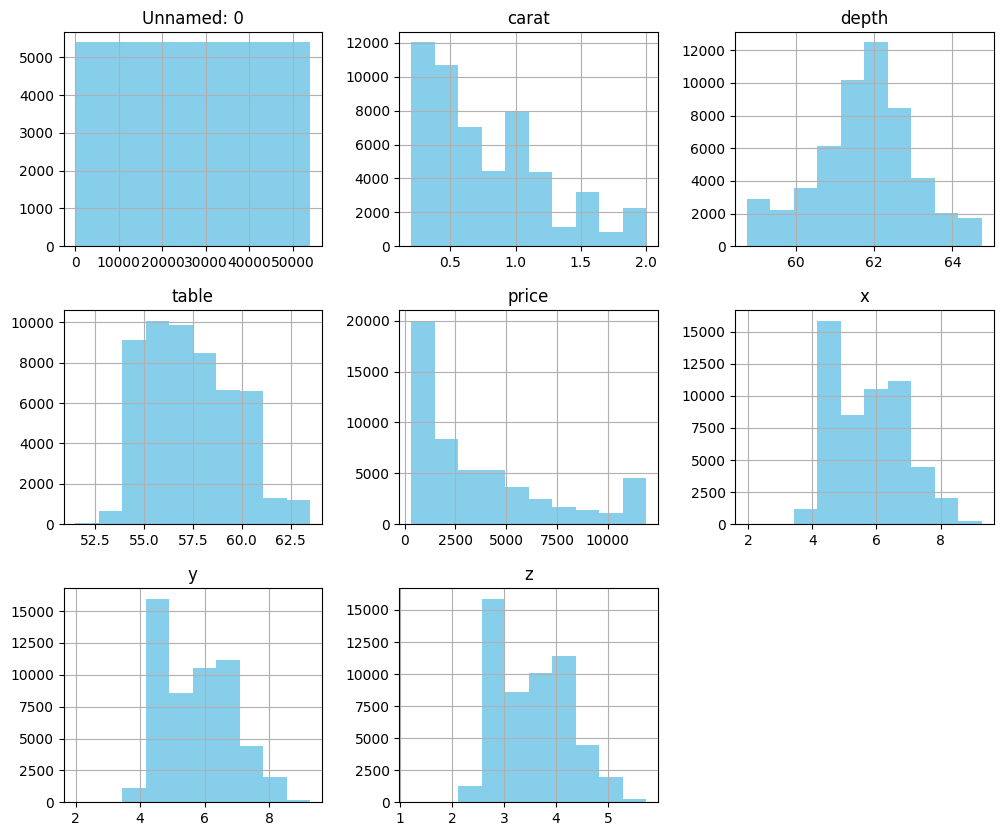

In [ ]:
df.hist(figsize=(12,10), color='skyblue')
plt.show()

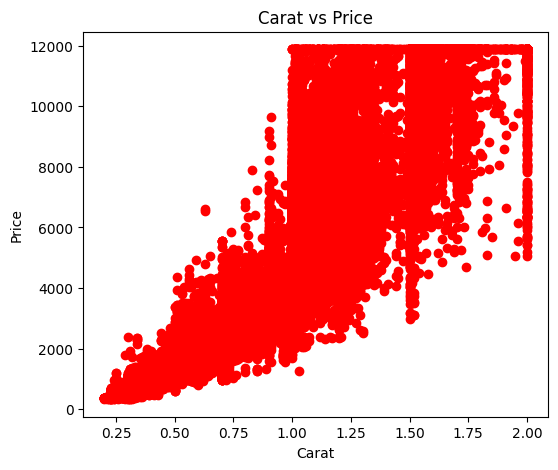

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df['carat'], df['price'], color='red')
plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Carat vs Price")
plt.show()

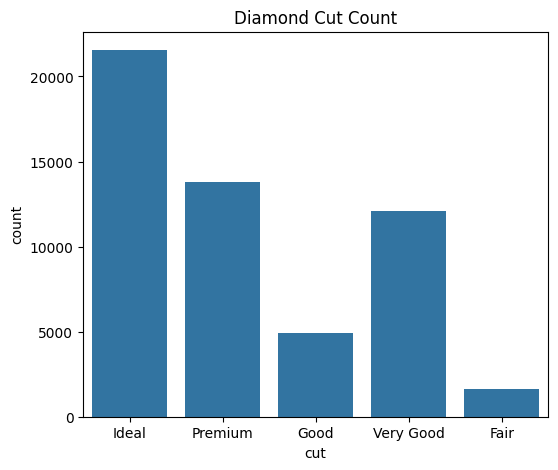

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(x='cut', data=df)
plt.title("Diamond Cut Count")
plt.show()

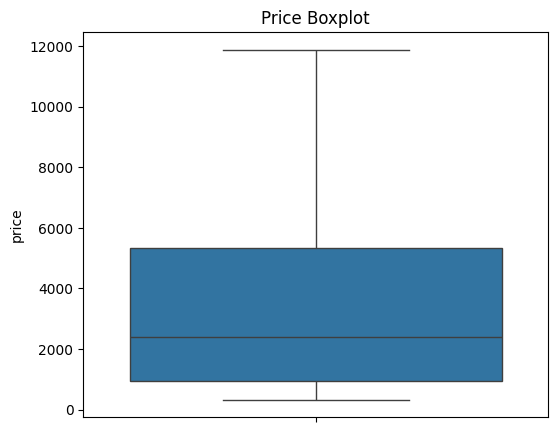

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df['price'])
plt.title("Price Boxplot")
plt.show()

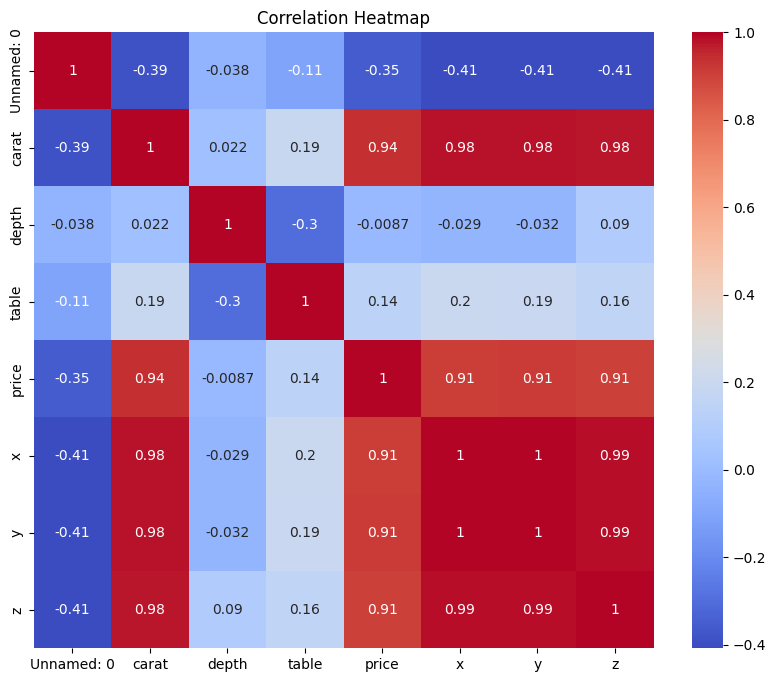

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()